In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from lightgbm import LGBMClassifier

# Get project root
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import utils.evaluation as evaluate
import utils.visualization_utils as visualize

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = Path("../data")
OUTPUT_DIR  = Path("../data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Load Data

In [28]:
train_df = pd.read_parquet(DATA_DIR / "train_features.parquet", engine="fastparquet")
holdout_df = pd.read_parquet(DATA_DIR / "holdout_features.parquet", engine="fastparquet")
oot_df = pd.read_parquet(DATA_DIR / "oot_features.parquet", engine="fastparquet")

print("Train shape   :", train_df.shape)
print("Holdout shape :", holdout_df.shape)
print("OOT shape     :", oot_df.shape)

Train shape   : (1341934, 32)
Holdout shape : (210771, 32)
OOT shape     : (201450, 32)


In [29]:
train_df.columns


Index(['TRANSACTION_ID', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_DATETIME', 'TX_DAY',
       'TX_FRAUD_SCENARIO', 'TX_AMOUNT', 'hour', 'distance', 'Z_score',
       'amount_to_mean_ratio', 'peer_group_amount_ratio', 'is_night',
       'tx_count_1h', 'tx_count_4h', 'night_velocity',
       'terminal_fraud_rate_3d', 'terminal_fraud_rate_7d',
       'terminal_fraud_rate_28d', 'night_fraud_rate', 'PREV_TX_AMOUNT_lag1',
       'PREV_TX_AMOUNT_lag2', 'PREV_TX_AMOUNT_lag3', 'ratio_to_lag1',
       'ratio_to_lag2', 'ratio_to_lag3', 'is_test_tx_sequence',
       'neigh_fraud_rate', 'mean_nb_tx_per_day', 'nb_terminals', 'day_of_week',
       'TX_FRAUD'],
      dtype='str')

In [37]:
COLS_TO_DROP = ["TX_FRAUD", "TX_FRAUD_SCENARIO", 
                "day_of_week", "nb_terminals", "mean_nb_tx_per_day",
                "TX_DATETIME"]
TARGET = "TX_FRAUD"

In [38]:
# ==========================
# Training Set
# ==========================
X_train = train_df.drop(columns=COLS_TO_DROP)
y_train = train_df[TARGET]

# ==========================
# Holdout (Validation) Set
# ==========================
X_holdout = holdout_df.drop(columns=COLS_TO_DROP)
y_holdout = holdout_df[TARGET]

# ==========================
# Out-of-Time (Final Test) Set
# ==========================
X_oot = oot_df.drop(columns=COLS_TO_DROP)
y_oot = oot_df[TARGET]

# ==========================
# Check shapes
# ==========================
print("Train   :", X_train.shape, y_train.shape)
print("Holdout :", X_holdout.shape, y_holdout.shape)
print("OOT     :", X_oot.shape, y_oot.shape)

Train   : (1341934, 26) (1341934,)
Holdout : (210771, 26) (210771,)
OOT     : (201450, 26) (201450,)


In [39]:
# define preprocess pipeline
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)
    ]
)

### Train LightGBM

In [63]:
lgbm_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", LGBMClassifier(
        class_weight="balanced",
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1
    ))
])

In [64]:
# fit model on train data
lgbm_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['TRANSACTION_ID','CUSTOMER_ID','TERMINAL_ID',...,'ratio_to_lag3', 'is_test_tx_sequence','neigh_fraud_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 


==================== LightGBM - Holdout (Threshold = 0.5) ====================
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    208887
       Fraud       0.47      0.93      0.63      1884

    accuracy                           0.99    210771
   macro avg       0.74      0.96      0.81    210771
weighted avg       0.99      0.99      0.99    210771

ROC-AUC:  0.9742
PR-AUC:   0.9176


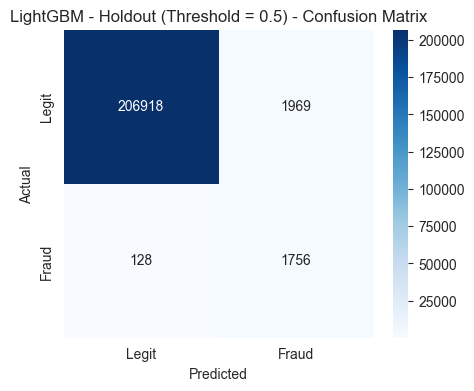

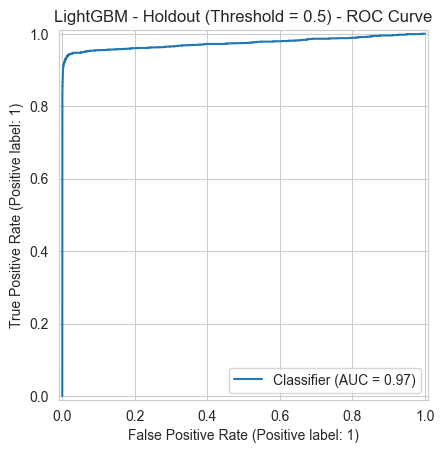

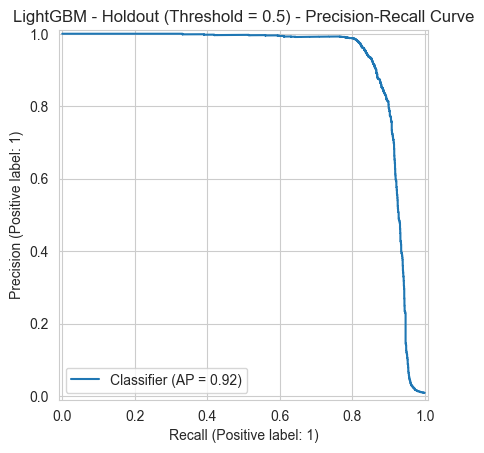

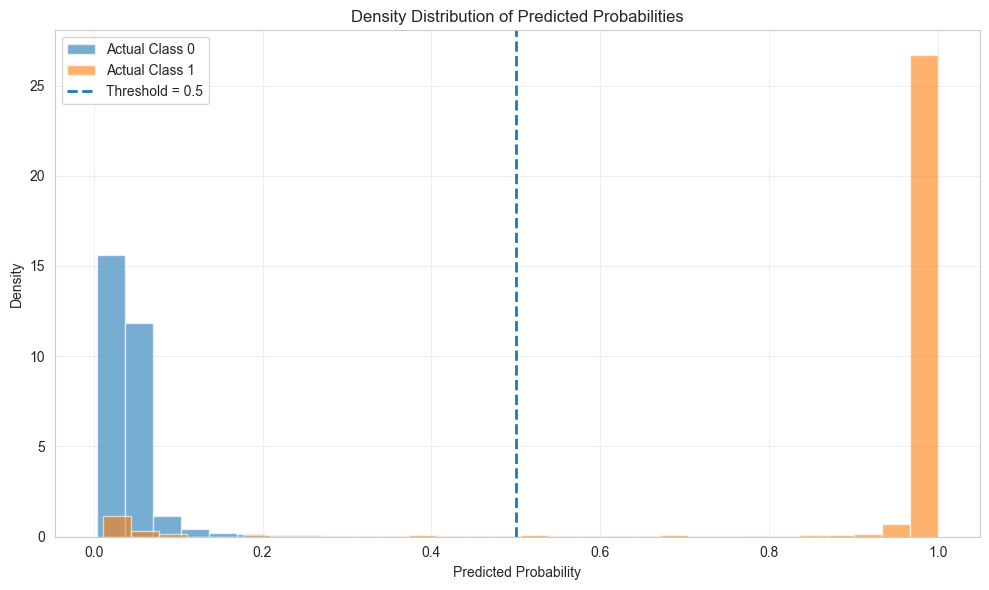

In [65]:
# Predicted probabilities
y_prob_holdout = lgbm_pipe.predict_proba(X_holdout)[:, 1]

# Predictions using threshold = 0.5
y_pred_holdout = lgbm_pipe.predict(X_holdout)

# Evaluation
holdout_results = evaluate.evaluate_w_visualization(
    y_test=y_holdout,
    y_pred=y_pred_holdout,
    y_prob=y_prob_holdout,
    model_name="LightGBM - Holdout (Threshold = 0.5)"
)

# Probability distribution
visualize.plot_probability_distribution(
    y_holdout,
    y_prob_holdout,
    threshold=0.5
)

In [66]:
# find best threshold
lgbm_best_threshold, lgbm_results_df = evaluate.find_best_threshold(
    y_holdout,
    y_prob_holdout,
    metric="f1"
)


Best threshold (by f1): 0.99
Precision: 0.946
Recall:    0.839
F1:        0.889



==================== LightGBM - Holdout (Threshold = 0.990) ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    208887
       Fraud       0.95      0.84      0.89      1884

    accuracy                           1.00    210771
   macro avg       0.97      0.92      0.94    210771
weighted avg       1.00      1.00      1.00    210771

ROC-AUC:  0.9742
PR-AUC:   0.9176


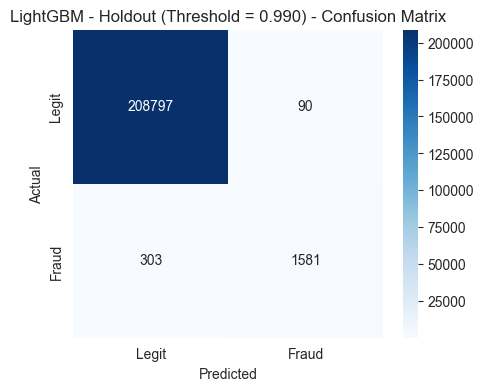

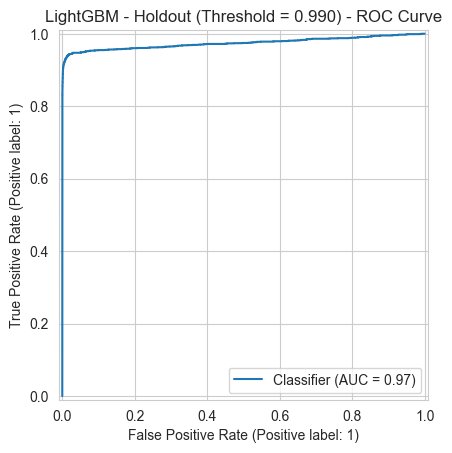

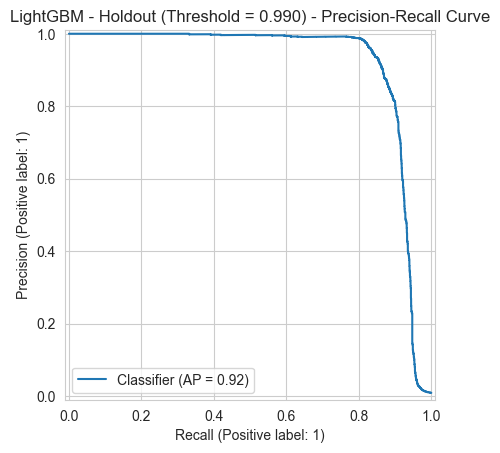

In [57]:
y_holdout_pred = (y_prob_holdout >= lgbm_best_threshold).astype(int)

lgbm_holdout_eval = evaluate.evaluate_w_visualization(
    y_test=y_holdout,
    y_pred=y_holdout_pred,
    y_prob=y_prob_holdout,
    model_name=f"LightGBM - Holdout (Threshold = {lgbm_best_threshold:.3f})"
)

## Predict probabilities on OOT


==================== LightGBM - OOT (Threshold = 0.990) ====================
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    199661
       Fraud       0.96      0.84      0.90      1789

    accuracy                           1.00    201450
   macro avg       0.98      0.92      0.95    201450
weighted avg       1.00      1.00      1.00    201450

ROC-AUC:  0.9749
PR-AUC:   0.9209


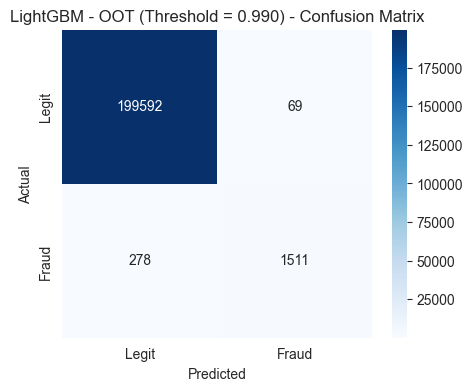

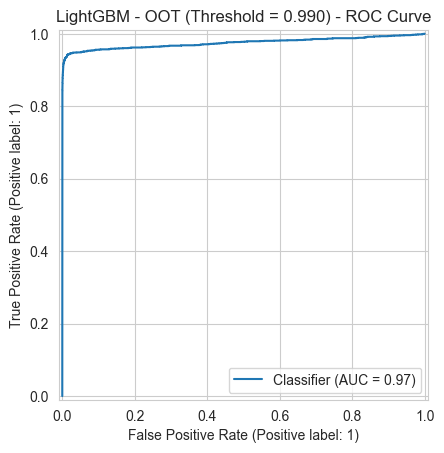

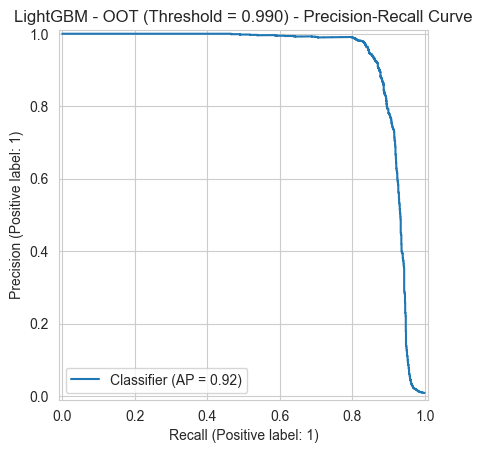

In [58]:
# Predict probabilities on OOT
y_prob_oot = lgbm_pipe.predict_proba(X_oot)[:, 1]

# Apply threshold learned from Holdout
y_oot_pred = (y_prob_oot >= lgbm_best_threshold).astype(int)

# Final evaluation
lgbm_oot_eval = evaluate.evaluate_w_visualization(
    y_test=y_oot,
    y_pred=y_oot_pred,
    y_prob=y_prob_oot,
    model_name=f"LightGBM - OOT (Threshold = {lgbm_best_threshold:.3f})"
)